### 1. SETUP & DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
# Note: Adjust paths if your lakehouse/local folder structure differs
match   = pd.read_csv("../data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("../data/gold_match_tickets.csv")
context = pd.read_csv("../data/gold_match_context.csv")

# Filter for home matches and merge
match = match[match["is_home_match"] == True]
df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

# Handle potential suffix issues from merges
if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

# Clean up
df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned"])
df["match_date"] = pd.to_datetime(df["match_date"])
df = df.sort_values("match_date").reset_index(drop=True)

print(f"Data successfully loaded. Total historical home matches: {len(df)}")

Data successfully loaded. Total historical home matches: 72


### 2. EXPLORATORY ANALYSIS

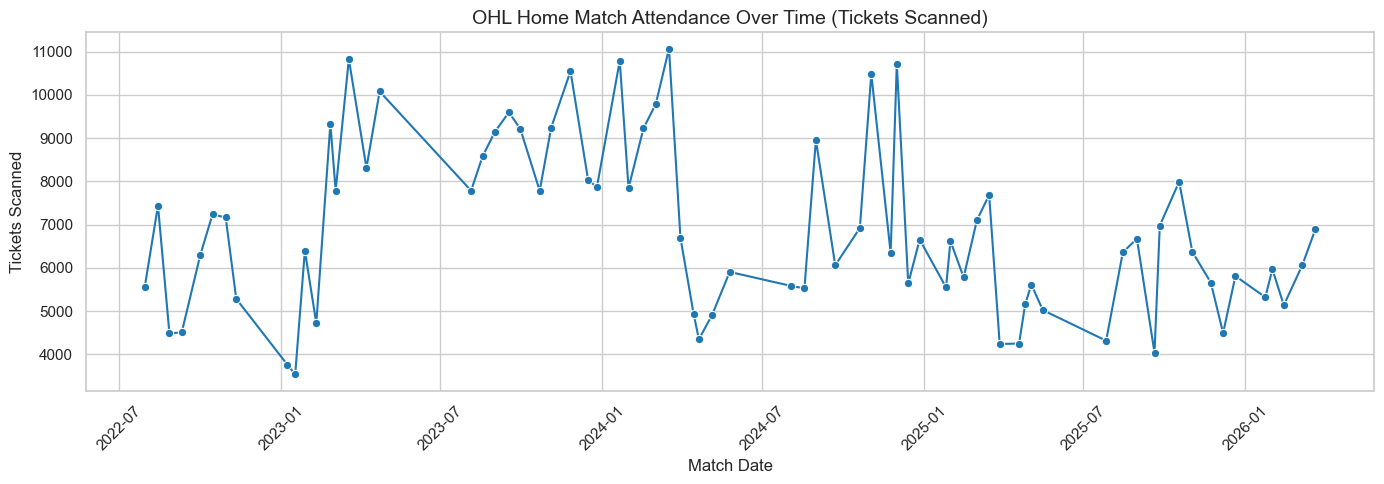

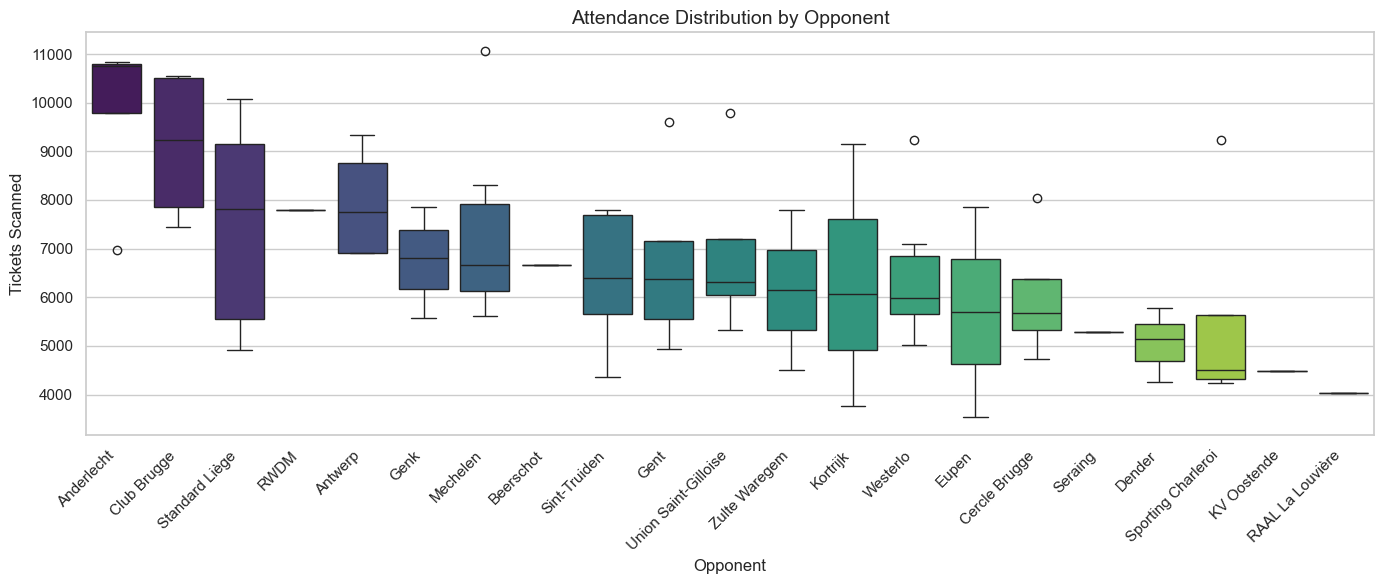

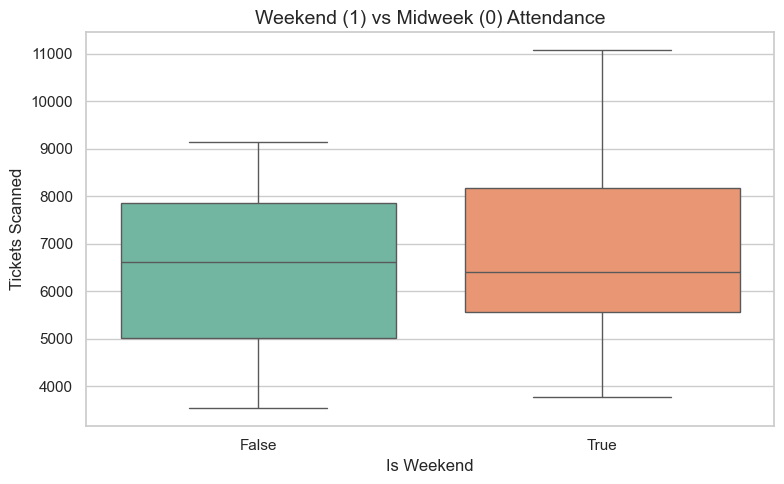

In [2]:
sns.set_theme(style="whitegrid")

# 1. Attendance over time
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x="match_date", y="tickets_scanned", marker="o", color="#1f77b4")
plt.title("OHL Home Match Attendance Over Time (Tickets Scanned)", fontsize=14)
plt.xlabel("Match Date")
plt.ylabel("Tickets Scanned")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Attendance by Opponent (Boxplot)
# Sorting by median attendance to show high vs low draw opponents
plt.figure(figsize=(14, 6))
order = df.groupby("away_team")["tickets_scanned"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="away_team", y="tickets_scanned", order=order, palette="viridis")
plt.title("Attendance Distribution by Opponent", fontsize=14)
plt.xlabel("Opponent")
plt.ylabel("Tickets Scanned")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Weekend vs Midweek Attendance
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_weekend", y="tickets_scanned", palette="Set2")
plt.title("Weekend (1) vs Midweek (0) Attendance", fontsize=14)
plt.xlabel("Is Weekend")
plt.ylabel("Tickets Scanned")
plt.tight_layout()
plt.show()

### 3. FEATURE ENGINEERING & BASELINES

In [3]:
# Ensure correct data types
df["matchday"] = pd.to_numeric(df["matchday"], errors="coerce")
df["is_weekend"] = pd.to_numeric(df["is_weekend"], errors="coerce")
df["academic_week"] = pd.to_numeric(df["academic_week"], errors="coerce")
df["stage"] = df["stage"].fillna("None").astype(str)

# Average attendences in the last two games
df["rolling_avg_2"] = df["tickets_scanned"].shift(1).rolling(window=2).mean()

# Average attendece of the season so far
df["season_expanding_avg"] = df["tickets_scanned"].shift(1).expanding().mean()

# Opponent Baselines
df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(
    lambda x: x.shift().expanding().mean()
)
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"])

# Same-fixture last year baseline
df["same_fixture_baseline"] = df.groupby("away_team")["tickets_scanned"].shift(1)
df["same_fixture_baseline"] = df["same_fixture_baseline"].fillna(df["season_expanding_avg"])

# Define Final Model Features
model_features = [
    "opponent_avg",
    "matchday",
    "is_weekend",
    "academic_week",
    "stage",
    "away_team",
    "rolling_avg_2",
    "season_expanding_avg",
]

# Drop rows where rolling features can't be calculated (start of history)
df_model = df.dropna(subset=["rolling_avg_2", "opponent_avg"]).reset_index(drop=True)
print(f"Features engineered. Ready for modeling with {len(df_model)} matches.")

Features engineered. Ready for modeling with 70 matches.


### 4. MODELING & ERROR ANALYSIS

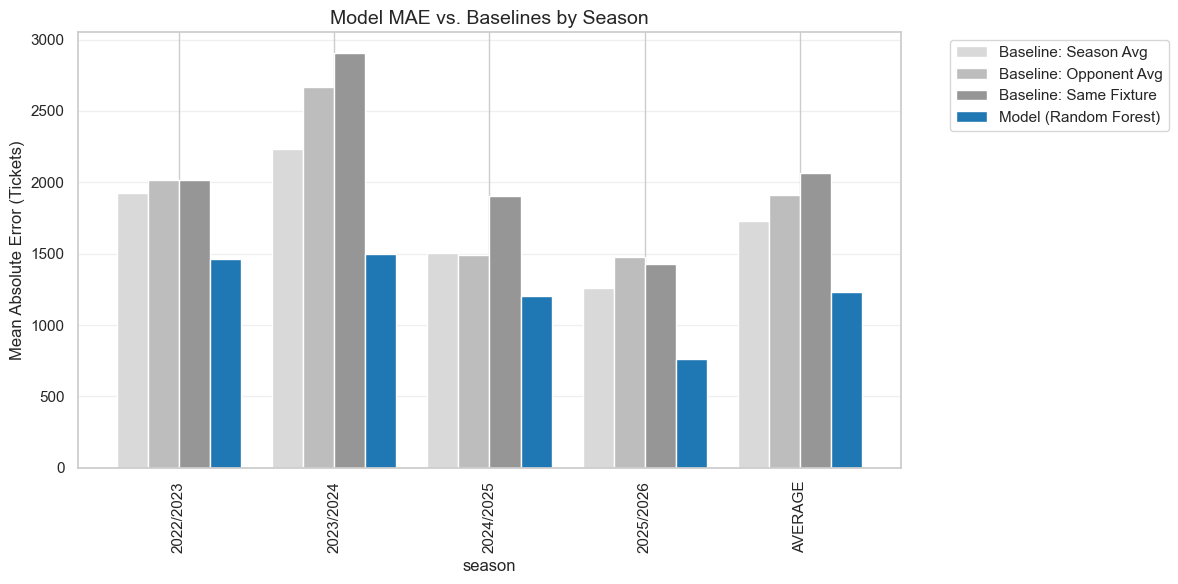

--- OVERALL PERFORMANCE METRICS ---


,Baseline: Season Avg,Baseline: Opponent Avg,Baseline: Same Fixture,Model (Random Forest),Model RMSE,Model R²
season,,,,,,
2022/2023,1922.12,2017.81,2017.81,1463.63,1656.70,0.44
2023/2024,2236.25,2671.30,2905.87,1497.68,1750.57,0.17
2024/2025,1504.93,1491.15,1905.59,1204.28,1665.24,0.09
2025/2026,1261.52,1478.53,1424.77,762.56,957.13,0.17
AVERAGE,1731.21,1914.70,2063.51,1232.04,1507.41,0.22



--- WORST-CASE ERROR ANALYSIS (2025/2026 Season) ---
Comparing the absolute maximum errors to prove the model minimizes severe operational misses:


,Max Error (Worst Miss)
Model,
Random Forest,1784.0
Opponent Avg,3802.0
Same Fixture,3746.0



Top 3 Worst Model Misses in the Last Season:


,Date,Opponent,Actual,Model_Pred,Model_Abs_Err,Opp_Avg_Abs_Err
3,2025-09-20,RAAL La Louvière,4036.0,5820.0,1784.0,3020.0
5,2025-10-18,Club Brugge,7992.0,6421.0,1571.0,1498.0
8,2025-12-07,Zulte Waregem,4494.0,5960.0,1466.0,3291.0


In [ ]:
def evaluate_and_analyze_errors(df, features):
    seasons = sorted(df["season"].unique())
    season_results = []
    all_predictions = []
    
    required_cols = list(set(features + ["match_id", "match_date", "away_team", "tickets_scanned", "season", "opponent_avg", "same_fixture_baseline"]))
    df_clean = df.dropna(subset=required_cols).copy().reset_index(drop=True)

    for test_season in seasons:
        df_prior  = df_clean[df_clean["season"] != test_season].copy()
        df_target = df_clean[df_clean["season"] == test_season].copy().reset_index(drop=True)

        if len(df_prior) < 10 or len(df_target) < 3:
            continue

        actuals, preds, s_avg, o_avg, f_avg = [], [], [], [], []

        for i in range(len(df_target)):
            test_match = df_target.iloc[[i]]
            train_matches = pd.concat([df_prior, df_target.iloc[:i]])

            cat_cols = train_matches[features].select_dtypes(exclude=[np.number]).columns.tolist()
            X_train = pd.get_dummies(train_matches[features], columns=cat_cols, drop_first=True)
            X_test  = pd.get_dummies(test_match[features], columns=cat_cols, drop_first=True).reindex(columns=X_train.columns, fill_value=0)
            
            rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
            rf.fit(X_train, train_matches["tickets_scanned"])
            
            pred = rf.predict(X_test)[0]
            actual = test_match["tickets_scanned"].values[0]
            
            curr_s_avg = train_matches["tickets_scanned"].mean()
            curr_o_avg = test_match["opponent_avg"].values[0]
            curr_f_avg = test_match["same_fixture_baseline"].values[0]
            
            actuals.append(actual)
            preds.append(pred)
            s_avg.append(curr_s_avg)
            o_avg.append(curr_o_avg)
            f_avg.append(curr_f_avg)
            
            all_predictions.append({
                "Season": test_season,
                "Date": test_match["match_date"].values[0],
                "Opponent": test_match["away_team"].values[0],
                "Actual": actual,
                "Model_Pred": pred,
                "Opp_Avg_Pred": curr_o_avg,
                "Same_Fix_Pred": curr_f_avg,
                "Model_Abs_Err": abs(actual - pred),
                "Opp_Avg_Abs_Err": abs(actual - curr_o_avg),
                "Same_Fix_Abs_Err": abs(actual - curr_f_avg)
            })

        r2 = r2_score(actuals, preds)
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        
        season_results.append({
            "season": test_season,
            "Baseline: Season Avg": mean_absolute_error(actuals, s_avg),
            "Baseline: Opponent Avg": mean_absolute_error(actuals, o_avg),
            "Baseline: Same Fixture": mean_absolute_error(actuals, f_avg),
            "Model (Random Forest)": mean_absolute_error(actuals, preds),
            "Model RMSE": rmse,
            "Model R²": r2
        })

    # Create Results DataFrame and calculate AVERAGE row
    results_df = pd.DataFrame(season_results).set_index("season")
    results_df.loc["AVERAGE"] = results_df.mean()

    # 1. Bar Chart Visualization (as in original code)
    mae_columns = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model (Random Forest)"]
    colors = ["#d9d9d9", "#bdbdbd", "#969696", "#1f77b4"]
    
    ax = results_df[mae_columns].plot(kind="bar", figsize=(12, 6), color=colors, width=0.8)
    plt.title("Model MAE vs. Baselines by Season", fontsize=14)
    plt.ylabel("Mean Absolute Error (Tickets)")
    plt.grid(axis='y', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    print("--- OVERALL PERFORMANCE METRICS ---")
    display(results_df.round(2))

    # 2. Worst-Case Error Analysis on Latest Season
    latest_season = sorted([s for s in seasons if s != "AVERAGE"])[-1]
    last_season_df = pd.DataFrame([p for p in all_predictions if p["Season"] == latest_season])
    
    print(f"\n--- WORST-CASE ERROR ANALYSIS ({latest_season} Season) ---")
    
    worst_case_metrics = pd.DataFrame({
        "Model": ["Random Forest", "Opponent Avg", "Same Fixture"],
        "Max Error (Worst Miss)": [
            last_season_df["Model_Abs_Err"].max(),
            last_season_df["Opp_Avg_Abs_Err"].max(),
            last_season_df["Same_Fix_Abs_Err"].max()
        ]
    }).set_index("Model")
    display(worst_case_metrics.round(0))

    print("\nTop 3 Worst Model Misses in the Last Season:")
    worst_misses = last_season_df.sort_values(by="Model_Abs_Err", ascending=False).head(3)
    display(worst_misses[["Date", "Opponent", "Actual", "Model_Pred", "Model_Abs_Err", "Opp_Avg_Abs_Err"]].round(0))
    
    return results_df, last_season_df

results, error_details = evaluate_and_analyze_errors(df_model, model_features)

### 5. FEATURE IMPORTANCE ANALYSIS

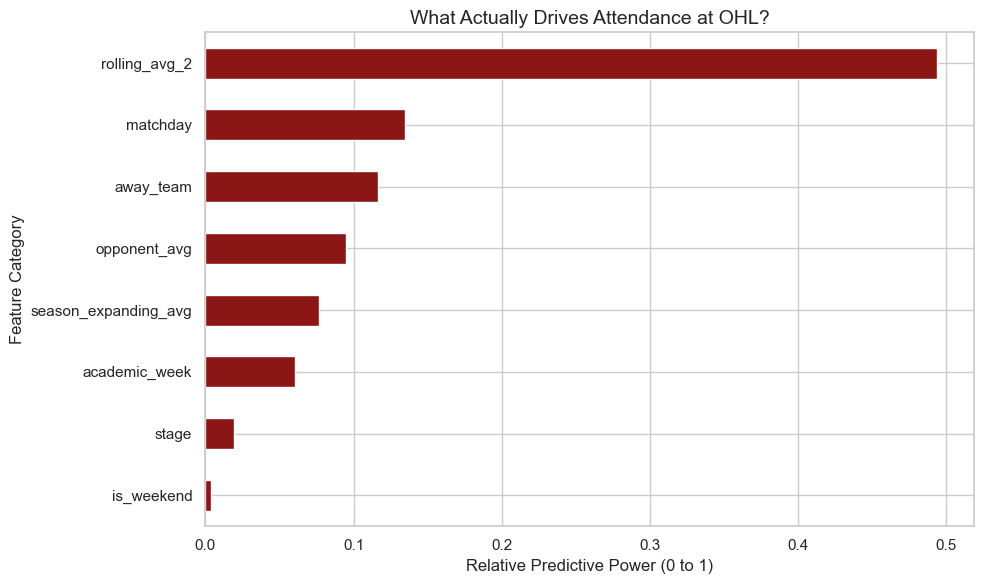

In [5]:
# To get a global view of feature importance, we train one model on all available data
cat_cols = df_model[model_features].select_dtypes(exclude=[np.number]).columns.tolist()
X_full = pd.get_dummies(df_model[model_features], columns=cat_cols, drop_first=True)
y_full = df_model["tickets_scanned"]

rf_importance = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_importance.fit(X_full, y_full)

# Aggregate dummy variable importances back to their original parent features
importances = rf_importance.feature_importances_
feature_names = X_full.columns
importance_dict = {feat: 0 for feat in model_features}

for feat, imp in zip(feature_names, importances):
    for base_feat in model_features:
        if feat.startswith(base_feat):
            importance_dict[base_feat] += imp
            break

# Plot
imp_df = pd.DataFrame.from_dict(importance_dict, orient='index', columns=['Importance']).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
imp_df.plot(kind='barh', color='#8c1515', legend=False, ax=plt.gca())
plt.title("What Actually Drives Attendance at OHL?", fontsize=14)
plt.xlabel("Relative Predictive Power (0 to 1)")
plt.ylabel("Feature Category")
plt.tight_layout()
plt.show()

### 6. SEQUENTIAL MATCH VISUALIZATION

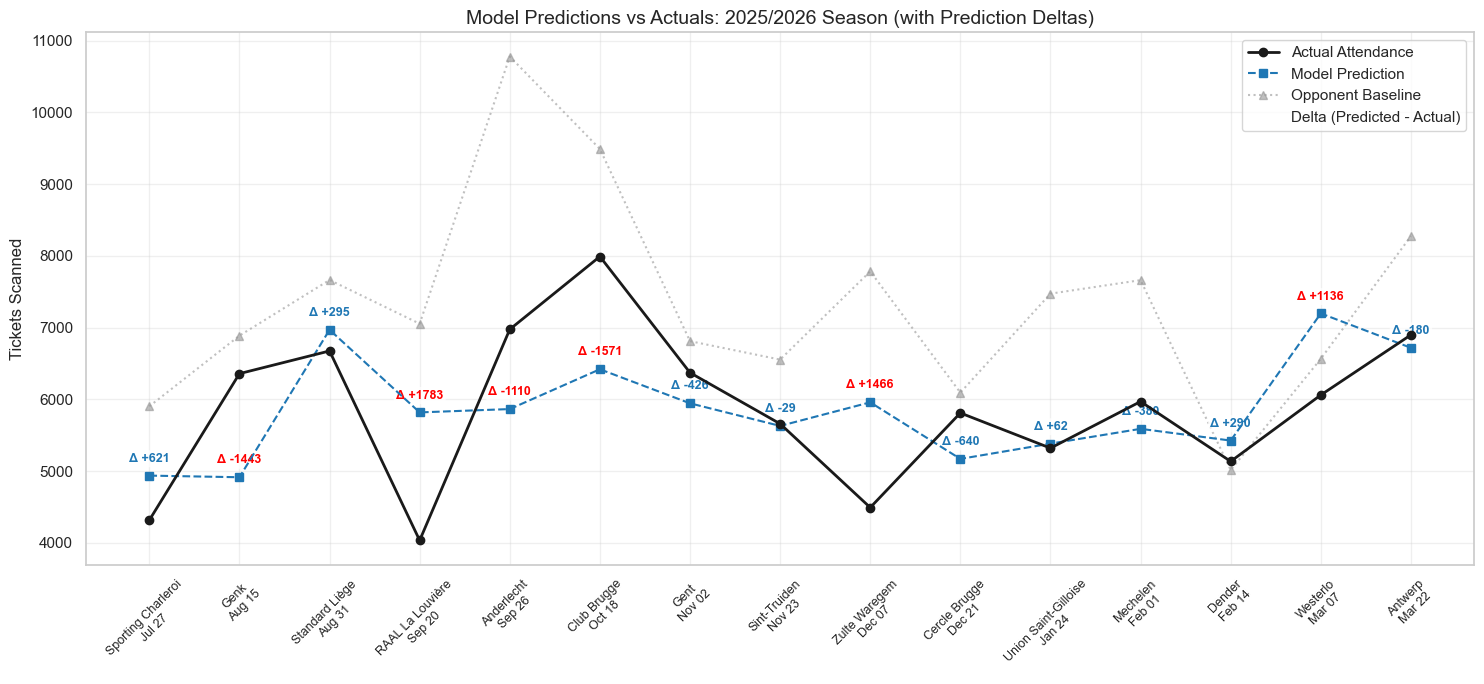

In [ ]:
def plot_current_season_with_deltas(df, features, target_season="2025/2026"): 
    # Update target_season to the most recent full season in your data
    df_prior = df[df["season"] != target_season].copy()
    df_target = df[df["season"] == target_season].copy().reset_index(drop=True)

    if df_target.empty:
        print(f"No data found for season {target_season}. Please choose a valid season.")
        return

    dates, opponents, actuals, preds, opp_bl = [], [], [], [], []

    for i in range(len(df_target)):
        test_match = df_target.iloc[[i]]
        train_matches = pd.concat([df_prior, df_target.iloc[:i]])

        cat_cols = train_matches[features].select_dtypes(exclude=[np.number]).columns.tolist()
        X_train = pd.get_dummies(train_matches[features], columns=cat_cols, drop_first=True)
        X_test  = pd.get_dummies(test_match[features], columns=cat_cols, drop_first=True).reindex(columns=X_train.columns, fill_value=0)
        
        rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        rf.fit(X_train, train_matches["tickets_scanned"])

        dates.append(test_match["match_date"].values[0])
        opponents.append(test_match["away_team"].values[0])
        actual = test_match["tickets_scanned"].values[0]
        pred = rf.predict(X_test)[0]
        
        actuals.append(actual)
        preds.append(pred)
        opp_bl.append(test_match["opponent_avg"].values[0])

    plt.figure(figsize=(15, 7))
    x = range(len(dates))
    
    # Plotting Lines
    plt.plot(x, actuals, 'ko-', label="Actual Attendance", linewidth=2, zorder=5)
    plt.plot(x, preds, 's--', color='#1f77b4', label="Model Prediction", zorder=4)
    plt.plot(x, opp_bl, '^:', color='#969696', label="Opponent Baseline", alpha=0.6, zorder=3)
    
    # Adding Delta Annotations (Model Pred - Actual)
    for i in range(len(actuals)):
        if not np.isnan(actuals[i]):
            delta = preds[i] - actuals[i]
            sign = "+" if delta > 0 else ""
            color = "red" if abs(delta) > 1000 else "#1f77b4"
            
            plt.annotate(
                f"Δ {sign}{int(delta)}", 
                (x[i], preds[i]), 
                textcoords="offset points", 
                xytext=(0, 10),
                ha='center', 
                fontsize=9, 
                fontweight='bold',
                color=color,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
            )
    
    # Formatting
    plt.xticks(x, [f"{o}\n{pd.Timestamp(d).strftime('%b %d')}" for o, d in zip(opponents, dates)], rotation=45, fontsize=9)
    plt.title(f"Model Predictions vs Actuals: {target_season}", fontsize=14)
    plt.ylabel("Tickets Scanned")
    
    # Update legend to explain the delta
    handles, labels = plt.gca().get_legend_handles_labels()
    import matplotlib.lines as mlines
    delta_marker = mlines.Line2D([], [], color='none', marker='$\Delta$', linestyle='None',
                              markersize=10, label='Delta (Predicted - Actual)')
    handles.append(delta_marker)
    
    plt.legend(handles=handles, loc="upper right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run for the latest available season in the model dataset
latest_season = df_model["season"].max()
plot_current_season_with_deltas(df_model, model_features, target_season=latest_season)